## Trabajo Práctico 1 - Tecnología Digital VI: Machine Learning
 
**Integrantes:** Lourdes Moreira, Juana Arslanian y Matías Cerdeira  

**Fecha de entrega:** 2 de septiembre de 2026

## Introducción

En este trabajo desarrollamos dos problemas de clasificación con el mismo conjunto de datos. En la Parte I vamos a analizar el problema de abandono de clientes, conocido como *Customer Churn*, utilizando un dataset de una empresa de telecomunicaciones y poniendo el foco en la prevención de *data leakage*, la validación y las métricas de negocio. La Parte II reformula el objetivo para predecir si un cliente con servicio de internet contrataría o no servicio de *streaming*.

## Parte I

### 1. Problema y Análisis Exploratorio de los datos

Una empresa de telecomunicaciones quiere identificar clientes con riesgo de abandonar el servicio. Cada fila representa un cliente e incluye información sobre su antigüedad, los servicios que tiene contratados, el tipo de contrato, su forma de pago y sus cargos mensuales, entre otras variables. La variable que queremos predecir, es decir, el target `Churn` vale `Yes` cuando el cliente abandonó el servicio. 

Anticipar qué clientes tienen mayor probabilidad de irse permitiría dirigir acciones de retención, como ofrecer descuentos a tiempo. Sin embargo, el objetivo no es predecir muchos `No`, sino encontrar una proporción útil de las fugas sin enviar descuentos indiscriminadamente. Por eso más adelante contrastamos *precision* y *recall* y no evaluamos el modelo solo con *accuracy*.

De este modo, comenzamos cargando los datos y miramos las primeras 5 filas para ver qué variables incluye el dataset y obtener un panorama más claro a la hora de armar el modelo.

In [9]:
import pandas as pd

datos = pd.read_csv("dataset Telco Customer Churn.csv", na_values=[" "]) 
#aclaramos cómo tratar a los vacíos para que pandas pueda leer TotalCharges como columna númerica y no como texto
print("Filas:", datos.shape[0], "| Columnas:", datos.shape[1])


datos.head()

Filas: 7043 | Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Detectamos variables categóricas y numéricas, y consultamos ciertos features que hacen más fácil entender el dataset. Estos features son numéricos:
- `tenure`: Es la cantidad de meses que el cliente lleva en la empresa.
- `TotalCharges`: Es el total acumulado que se le cobró durante toda su relación con la empresa.
- `MonthlyCharges`: importe que se le cobra al cliente mensualmente.

Luego, chequeamos si hay alguna columna que contenga datos faltantes, cuál es y cuántos posee, ya que puede contener información útil que no esté siendo bien procesada.

In [10]:
faltantes = datos.isna().sum()

faltantes[faltantes > 0]

TotalCharges    11
dtype: int64

Asimismo, armamos un resumen de las variables para ver si hay datos duplicados e incluye estadísticas descriptivas. 

In [11]:
print("Filas duplicadas:", datos.duplicated().sum())
print("IDs duplicados:", datos["customerID"].duplicated().sum())

resumen_numerico = datos[["tenure", "MonthlyCharges", "TotalCharges"]].describe().T
columnas_categoricas = [
    columna
    for columna in datos.columns
    if columna not in [
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
]
resumen_categorico = pd.DataFrame({
    "categorías": datos[columnas_categoricas].nunique(),
    "moda": datos[columnas_categoricas].mode().iloc[0],
    "frecuencia_moda": [
        datos[columna].value_counts().iloc[0]
        for columna in columnas_categoricas
    ],
})

print("Resumen de variables numéricas")
display(resumen_numerico.round(2))
print("Resumen de variables categóricas")
display(resumen_categorico)

Filas duplicadas: 0
IDs duplicados: 0
Resumen de variables numéricas


,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75
TotalCharges,7032.0,2283.30,2266.77,18.80,401.45,1397.48,3794.74,8684.80


Resumen de variables categóricas


,categorías,moda,frecuencia_moda
customerID,7043,0002-ORFBO,1
gender,2,Male,3555
SeniorCitizen,2,0.0,5901
Partner,2,No,3641
Dependents,2,No,4933
PhoneService,2,Yes,6361
MultipleLines,3,No,3390
InternetService,3,Fiber optic,3096
OnlineSecurity,3,No,3498
OnlineBackup,3,No,3088


#### Visualizaciones relevantes

#### Grafico 1: Distribución de la variable Churn

Nos interesa ver la distribución de la variable `Churn` porque es la variable objetivo.

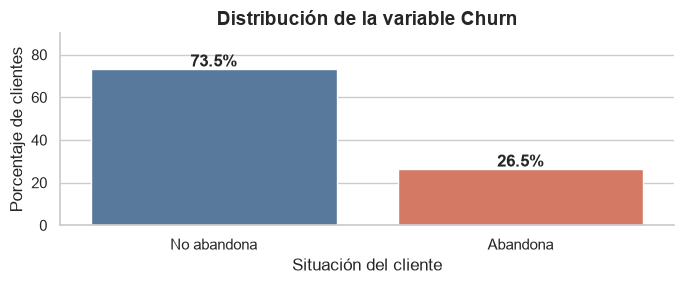

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns


porcentajes_churn = (
    datos["Churn"]
    .value_counts(normalize=True)
    .reindex(["No", "Yes"])
    .mul(100)
)

distribucion_churn = pd.DataFrame({
    "Situación": [
        "No abandona",
        "Abandona"
    ],
    "Porcentaje": porcentajes_churn.values
})

plt.figure(figsize=(7, 3))

ax = sns.barplot(
    data=distribucion_churn,
    x="Situación",
    y="Porcentaje",
    hue="Situación",
    palette={
        "No abandona": "#4C78A8",
        "Abandona": "#E76F51"
    },
    legend=False
)

for barra in ax.patches:
    porcentaje = barra.get_height()

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        porcentaje + 1,
        f"{porcentaje:.1f}%",
        ha="center",
        fontweight="bold"
    )

ax.set_title(
    "Distribución de la variable Churn",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Situación del cliente")
ax.set_ylabel("Porcentaje de clientes")
ax.set_ylim(0, 90)

sns.despine()
plt.tight_layout()
plt.show()

Notamos un desbalance ya que aproximadamente el 73,5% de los clientes no abandona el servicio, mientras que solo el 26,5% presenta fuga.

#### Gráfico 2: Relación entre el tipo de contrato y el abandono

La variable `Contract` indica la duración del contrato del cliente. Puede tomar tres valores: **mensual** (Month-to-month), **anual** (One year) o de **dos años** (Two year).

Para analizar su relación con el abandono, calculamos el porcentaje de clientes con `Churn = Yes` dentro de cada tipo de contrato.

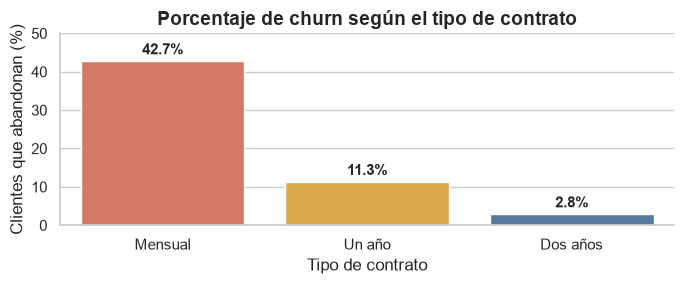

In [13]:
# Calculamos el porcentaje de churn para cada tipo de contrato
churn_por_contrato = (
    datos
    .assign(
        Churn_binario=(datos["Churn"] == "Yes").astype(int)
    )
    .groupby("Contract", as_index=False)["Churn_binario"]
    .mean()
)

churn_por_contrato["Porcentaje de churn"] = (
    churn_por_contrato["Churn_binario"] * 100
)

# Traducimos los nombres antes de construir el gráfico
traduccion_contratos = {
    "Month-to-month": "Mensual",
    "One year": "Un año",
    "Two year": "Dos años"
}

churn_por_contrato["Tipo de contrato"] = (
    churn_por_contrato["Contract"]
    .map(traduccion_contratos)
)

orden_contratos = [
    "Mensual",
    "Un año",
    "Dos años"
]

# Construimos el gráfico
sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 3))

ax = sns.barplot(
    data=churn_por_contrato,
    x="Tipo de contrato",
    y="Porcentaje de churn",
    order=orden_contratos,
    hue="Tipo de contrato",
    palette={
        "Mensual": "#E76F51",
        "Un año": "#F2B134",
        "Dos años": "#4C78A8"
    },
    legend=False
)

# Mostramos el porcentaje encima de cada barra
for barra in ax.patches:
    porcentaje = barra.get_height()

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        porcentaje + 1,
        f"{porcentaje:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "Porcentaje de churn según el tipo de contrato",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Tipo de contrato")
ax.set_ylabel("Clientes que abandonan (%)")
ax.set_ylim(0, 50)

sns.despine()
plt.tight_layout()
plt.show()

El gráfico muestra una relación clara entre la duración del contrato y la probabilidad de abandono. Aproximadamente el 42,7% de los clientes con contrato mensual abandona el servicio, mientras que este porcentaje disminuye al 11,3% entre quienes tienen contratos de un año y al 2,8% entre quienes poseen contratos de dos años.

Esto sugiere que los clientes con contratos de mayor duración presentan una relación más estable con la empresa. En cambio, quienes tienen contratos mensuales pueden cancelar con mayor facilidad y constituyen el grupo con mayor riesgo de churn. Por lo tanto, `Contract` podría ser una variable relevante para predecir el abandono.

#### Gráfico 3: Relación entre los cargos mensuales y el abandono

La variable `MonthlyCharges` representa el importe mensual que paga cada cliente. Para analizar su relación con `Churn`, comparamos la distribución de los cargos mensuales entre quienes permanecieron en la empresa y quienes abandonaron el servicio.


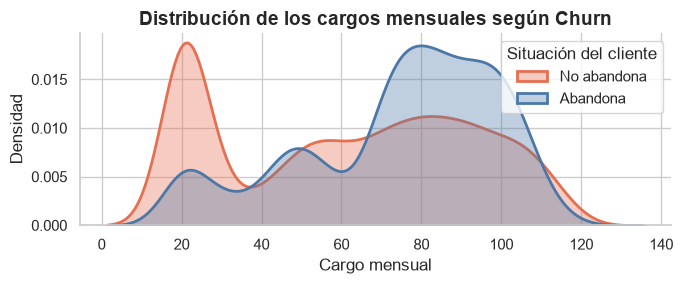

In [14]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 3))

sns.kdeplot(
    data=datos[datos["Churn"] == "No"],
    x="MonthlyCharges",
    fill=True,
    color="#E76F51",
    alpha=0.35,
    linewidth=2,
    label="No abandona"
)

sns.kdeplot(
    data=datos[datos["Churn"] == "Yes"],
    x="MonthlyCharges",
    fill=True,
    color="#4C78A8",
    alpha=0.35,
    linewidth=2,
    label="Abandona"
)

plt.title(
    "Distribución de los cargos mensuales según Churn",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Cargo mensual")
plt.ylabel("Densidad")
plt.legend(title="Situación del cliente")

sns.despine()
plt.tight_layout()
plt.show()

El gráfico muestra que los clientes que abandonaron el servicio presentan una mayor concentración en los cargos mensuales elevados, especialmente alrededor de los 70 a 100. En cambio, entre quienes no abandonaron aparece una concentración importante de clientes con cargos mensuales bajos, cercanos a 20.

En promedio, los clientes que abandonaron pagaban aproximadamente 74,44 por mes, mientras que quienes permanecieron pagaban alrededor de 61,27. Esto indica que existe una asociación entre cargos mensuales más elevados y una mayor presencia de churn, por lo que ``MonthlyCharges`` podría ser una variable relevante para el modelo.

Sin embargo, el gráfico muestra una asociación y no permite afirmar que un cargo mensual elevado sea, por sí solo, la causa del abandono.

### Anomalías y estrategia de faltantes

`TotalCharges` debería ser numérica, pero pandas la carga como texto porque contiene 11 valores formados solo por espacios. Sin embargo, al cargar el archivo indicamos que los espacios `" "` deben interpretarse como `NaN`, lo que permite que pandas reconozca la columna como numérica. 

Vemos que los 11 valores faltantes corresponden a clientes con `tenure = 0`, es decir, cuentas recién iniciadas que todavía no han acumulado cargos. Por eso completamos esos casos con `TotalCharges = 0` y no imputamos la media global, por ejemplo, porque introduciría un acumulado ficticio muy alto. 

Esta corrección la hicimos antes de dividir los datos porque si no deberíamos separar entre X para Train y X para Test según cayeron y de esta manera resulta más sencillo. Además, no produce *data leakage* dado que no utiliza una media, mediana ni ninguna estadística calculada a partir del resto del dataset. Sin embargo, si hubiéramos utilizado una media o mediana, habría sido necesario calcularla utilizando solamente el conjunto de entrenamiento, ya que sino el promedio incluiría también a los clientes que después quedarían en test.

Si no detectáramos estos espacios, `TotalCharges` podría quedar interpretada como una variable de texto. En ese caso no se podría escalar correctamente como una variable numérica y el modelo podría fallar o tratar cada importe como una categoría diferente, perdiendo la relación de orden entre los valores.

Asimismo, `SeniorCitizen` es leída como numérica pero es categórica binaria. Por ende, posteriormente la excluimos de las variables numéricas en el armado del modelo.

In [15]:
datos["TotalCharges"] = datos["TotalCharges"].fillna(0)

#verificamos
print("Cantidad de datos faltantes en todo el dataset:", datos.isna().sum().sum())

Cantidad de datos faltantes en todo el dataset: 0


### 2. Preprocesamiento y prevención de Data Leakage

El *data leakage* ocurre cuando el entrenamiento utiliza, directa o indirectamente, información que solo debería estar disponible al evaluar el modelo. Esto produce métricas demasiado optimistas y un desempeño que no se sostiene frente a datos nuevos.

En nuestro caso, primero completamos con cero los valores faltantes de `TotalCharges`, ya que como explicamos se trata de una regla justificada por `tenure = 0` y no de una estadística calculada con los datos. Luego dividimos el dataset en entrenamiento y test.

El escalado y la transformación de las variables categóricas se colocan dentro de un pipeline. De esta manera, durante la validación cruzada, estas transformaciones se ajustan solamente con los cuatro folds utilizados para entrenar y luego se aplican al fold de validación. Finalmente, el pipeline se ajusta con todo el conjunto de entrenamiento y se aplica al test sin volver a calcular sus parámetros. Si ajustáramos estas transformaciones antes del split, estaríamos incorporando información de test y produciendo *data leakage*.

Ahora separamos las features del target y organizamos donde: 
- `X` contiene las features utilizadas para predecir,
- `y` contiene lo que queremos predecir.

Excluimos `customerID` porque es único por persona y sirve sólo de identificador por lo que no contiene una señal generalizable y permitirlo como predictor agregaría miles de categorías sin significado. También, convertimos `Churn` en 0 y 1 para que después sea más fácil calcular las métricas, en vez de `Yes`, `No`.

In [16]:
from sklearn.model_selection import train_test_split

X = datos.drop(columns=["customerID", "Churn"])

y = datos["Churn"].map({
    "No": 0,
    "Yes": 1
})

Luego, dividimos el dataset en conjunto de entrenamiento y evaluación, en el que el 80% corresponde a Train y el 20% a Test, usamos una semilla fija = 42 para que la división sea siempre la misma pues sino cada ejecución puede producir un train y un test diferentes, y con la ayuda de `stratify=y` el conjunto de entrenamiento y test conservan aproximadamente la distribución del dataset completo (73,5% no/26,5% sí) para evitar que, por casualidad, una de las particiones tenga una proporción mucho mayor o menor de clientes que abandonan.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#### Armado del modelo

Utilizamos una regresión logística porque `Churn` es una variable binaria, donde cada cliente pertenece a la clase que abandona o a la que no abandona.

Con `OneHotEncoder`, separamos variables numéricas y categóricas porque `LogisticRegression` no puede trabajar directamente con textos y para no inventar un orden entre las categorías. Tras haber analizado el dataset, sabemos cuáles son las numéricas para discriminarlas y tratar todas las otras como categóricas. Asimismo, escalamos las numéricas para colocarlas en escalas comparables con `StandardScaler`. Esto es conveniente para una regresión logística porque utiliza regularización.

Tanto la transformación de las categorías como el escalado se colocan dentro de un pipeline. De esta manera se ajustan únicamente con los datos de entrenamiento. Si calculáramos el escalado con todo el dataset antes del split, estaríamos incorporando información del conjunto de test, lo que produciría *data leakage*.

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

variables_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]

variables_categoricas = [
    columna
    for columna in X.columns
    if columna not in variables_numericas
]

preprocesador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            StandardScaler(),
            variables_numericas
        ),
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            variables_categoricas
        )
    ]
)
modelo = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        (
            "regresion_logistica",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

### 3. Estrategia de validación

Como una partición *holdout* evalúa el modelo una sola vez, el resultado puede depender de qué clientes cayeron por casualidad en validación (o evaluación). Para evitar esto, una validación cruzada *K-Fold* con K = 5 folds sobre el conjunto de entrenamiento, permite que en cada iteración el modelo se entrene con cuatro folds y se valide con el restante. El proceso se repite hasta que cada fold haya sido utilizado una vez para validación y así cada parte del conjunto de entrenamiento se utiliza una vez para validar.

Esta estrategia permite obtener cinco mediciones diferentes en lugar de depender de una única partición *holdout*. De esta manera, podemos calcular un desempeño promedio y observar la variación de las métricas entre los cinco folds.

In [19]:
from sklearn.model_selection import KFold, cross_validate

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
resultados = cross_validate(
    modelo,
    X_train,
    y_train,
    cv=kfold,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ]
)
resultados_cv = pd.DataFrame({
    "Accuracy": resultados["test_accuracy"],
    "Precision": resultados["test_precision"],
    "Recall": resultados["test_recall"],
    "F1": resultados["test_f1"]
})

resultados_cv.round(3)

,Accuracy,Precision,Recall,F1
0,0.802,0.633,0.538,0.582
1,0.821,0.645,0.589,0.616
2,0.800,0.697,0.525,0.599
3,0.807,0.659,0.578,0.616
4,0.787,0.641,0.518,0.573


In [20]:
resultados_cv.mean().round(3)

Accuracy     0.804
Precision    0.655
Recall       0.550
F1           0.597
dtype: float64

Cada fila de la tabla corresponde a una partición distinta de la validación cruzada y vemos que los resultados son relativamente similares entre las cinco particiones: el *accuracy* promedio es aproximadamente 0,804, la *precision* 0,655, el *Recall* 0,550 y el *F1-Score* 0,597. Esto indica que la estimación del desempeño es razonablemente estable y no queda determinada por una única partición de entrenamiento y validación.

#### Stratified K-Fold

Creemos que usar **Stratified K-Fold** sería conveniente ya que el problema del **K-Fold** común es que no garantiza que cada fold tenga la misma proporción de clientes que abandonan. Entonces para un conjunto de datos **desbalanceados** como este, donde aproximadamente el 73,5% no abandona y el 26,5% sí, resulta buena estrategia utilizar `StratifiedKFold` que intenta mantener esa proporción en cada fold, haciendo que las evaluaciones sean más comparables.

Para comprobar si la estratificación produce resultados diferentes, repetimos la validación cruzada utilizando `StratifiedKFold`.

In [21]:
from sklearn.model_selection import StratifiedKFold, cross_validate

stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_stratified = cross_validate(
    modelo,
    X_train,
    y_train,
    cv=stratified_kfold,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ]
)

resultados_cv_stratified = pd.DataFrame({
    "Accuracy": resultados_stratified["test_accuracy"],
    "Precision": resultados_stratified["test_precision"],
    "Recall": resultados_stratified["test_recall"],
    "F1": resultados_stratified["test_f1"]
})

resultados_cv_stratified.round(3)

,Accuracy,Precision,Recall,F1
0,0.799,0.645,0.535,0.585
1,0.782,0.607,0.502,0.549
2,0.803,0.660,0.532,0.589
3,0.816,0.664,0.622,0.642
4,0.810,0.684,0.528,0.596


In [22]:
resultados_cv_stratified.mean().round(3)

Accuracy     0.802
Precision    0.652
Recall       0.544
F1           0.592
dtype: float64

Los resultados con `StratifiedKFold` son muy similares a los obtenidos previamente con `KFold`, por lo tanto, en este caso no se observa una diferencia importante en el desempeño promedio entre ambos métodos.

Sin embargo, consideramos que `StratifiedKFold` es la estrategia de validación más apropiada en este caso porque la variable objetivo `Churn` está desbalanceada. A diferencia de `KFold`, este método conserva aproximadamente la proporción de clientes que abandonan y no abandonan en cada partición. Esto permite que cada fold sea más representativo del conjunto de datos y que las métricas obtenidas sean más confiables.

### 4. Evaluación del modelo base

Las validaciones cruzadas anteriores se utilizaron para evaluar el modelo y comparar las estrategias K-Fold y Stratified K-Fold. Durante ese proceso se entrenaron copias temporales del pipeline, pero todavía no se construyó el modelo final.
Ahora entrenamos una nueva versión del pipeline utilizando todo el conjunto de entrenamiento disponible. Luego usamos este modelo para realizar las predicciones sobre test, que se mantuvo separado durante todo el proceso.

In [23]:
modelo.fit(X_train, y_train);

predicciones = modelo.predict(X_test)

Calculamos métricas para ver qué tan bueno resultó el modelo y las organizamos en una tabla.

In [24]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
accuracy = accuracy_score(y_test, predicciones)
precision = precision_score(y_test, predicciones)
recall = recall_score(y_test, predicciones)
f1 = f1_score(y_test, predicciones)
metricas = pd.DataFrame({
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-Score": [f1]
})

metricas.round(3)

,Accuracy,Precision,Recall,F1-Score
0,0.806,0.657,0.559,0.604


#### ¿Qué representa cada métrica?

El *accuracy* del modelo fue de 0,806, por lo que parecería predecir razonablemente bien.

La *precision* del modelo fue de 0,657. El modelo identificó a 318 clientes como posibles fugas y 209 de ellos realmente abandonaron. Esto significa que aproximadamente el 65,7% de los descuentos se enviaría a clientes que efectivamente estaban por abandonar, mientras que los otros 109 serían descuentos innecesarios.

El *recall* fue de 0,559. De los 374 clientes que realmente abandonaron, el modelo detectó a 209 y no identificó a los otros 165. Por lo tanto, logró encontrar aproximadamente el 55,9% de las fugas reales.

El *F1-Score* fue de 0,604 y resume en un único valor el equilibrio entre precision y recall. En este caso muestra que el modelo tiene un desempeño intermedio: no envía descuentos completamente al azar, pero todavía deja sin detectar una parte importante de las fugas.

#### Modelo naive

Un modelo *naive* que predice la clase mayoritaria tendría un **accuracy** del 73,5% el cual parece muy alto pero es solamente porque la mayoría de los clientes no abandona. Como el accuracy se calcula haciendo:
$$
\frac{Predicciones~correctas}{Total~de~casos}
$$
acertaría siempre que sea `Churn = 0`.

Sin embargo, este modelo no detectaría ningún cliente que abandona por ende su **recall** para la clase positiva sería 0 pues siempre predice `No`.

Esto muestra que la **accuracy** puede resultar engañosa cuando las clases están desbalanceadas y que debe complementarse con métricas como *precision*, *recall* y *F1-Score*. En este caso, *precision* indica qué proporción de los descuentos enviados llega realmente a personas que se iban, *recall* indica qué proporción de las fugas logramos contactar y *F1-score* resume el equilibrio entre ambas. De este modo, *accuracy* es una buena métrica pero no sirve como única métrica.

#### Matriz de confusión

Ahora calculamos la matriz de confusión que muestra los verdaderos negativos, falsos positivos, falsos negativos y verdaderos positivos.

In [25]:
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(y_test, predicciones)
matriz_confusion = pd.DataFrame(
    matriz,
    index=["Real: No abandona", "Real: Abandona"],
    columns=["Predice: No abandona", "Predice: Abandona"]
)

matriz_confusion

,Predice: No abandona,Predice: Abandona
Real: No abandona,926,109
Real: Abandona,165,209


### 5. Análisis de Negocio e Impacto de las Métricas

Creamos un segundo modelo aplicando la técnica de **Random Oversampling** sobre el conjunto de entrenamiento para lidiar con el desbalanceo de clases. En este caso, tenemos 4139 clientes que no abandonan y 1495 que sí. Para ello, creamos una tabla de entrenamiento que incluya el target y copiamos los datos de X y completamos a la clase minoritaria para que tenga la misma cantidad de observaciones, luego de hacer el Train/Test Split, porque si lo hiciéramos antes un mismo cliente podría terminar repetido tanto en train como en test, lo que sería *data leakage*. Por ende, no estamos creando clientes completamente nuevos sino repitiendo aleatoriamente observaciones de clientes que sí abandonaron. El conjunto de test no se modifica ya que debe conservar la distribución original para representar una evaluación realista.

La desventaja es que el oversampling repite observaciones existentes y puede aumentar el riesgo de sobreajuste, pero por ejemplo hacer **Undersampling** descartaría casi la mitad de la información de entrenamiento. De todas formas, resulta una técnica sencilla y adecuada para analizar cómo cambia el comportamiento del modelo cuando ambas clases tienen el mismo peso durante el entrenamiento.

In [26]:
y_train.value_counts()

Churn
0    4139
1    1495
Name: count, dtype: int64

In [27]:
from sklearn.utils import resample
from sklearn.base import clone

entrenamiento = X_train.copy()

entrenamiento["Churn"] = y_train

clase_mayoritaria = entrenamiento[
    entrenamiento["Churn"] == 0
]

clase_minoritaria = entrenamiento[
    entrenamiento["Churn"] == 1
]
clase_minoritaria_ampliada = resample(
    clase_minoritaria,
    replace=True,
    n_samples=len(clase_mayoritaria),
    random_state=42
)
entrenamiento_over = pd.concat([
    clase_mayoritaria,
    clase_minoritaria_ampliada
])
#para duplicar filas completas las habíamos unido pero las volvemos a separar para entrenar luego
X_train_over = entrenamiento_over.drop(
    columns="Churn"
)
y_train_over = entrenamiento_over["Churn"]
#verificamos el nuevo balance
y_train_over.value_counts()

Churn
0    4139
1    4139
Name: count, dtype: int64

Ahora que ambas clases tienen la misma cantidad de observaciones, creamos el nuevo modelo, lo entrenamos y evaluamos.

In [28]:
modelo_oversampling = clone(modelo)

modelo_oversampling.fit(
    X_train_over,
    y_train_over
);
predicciones_over = modelo_oversampling.predict(
    X_test
)

#### Métricas nuevas y comparación

Calculamos las métricas y comparamos con el modelo base.

In [29]:
accuracy_over = accuracy_score(
    y_test,
    predicciones_over
)

precision_over = precision_score(
    y_test,
    predicciones_over
)

recall_over = recall_score(
    y_test,
    predicciones_over
)

f1_over = f1_score(
    y_test,
    predicciones_over
)

comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Modelo base",
        "Modelo con oversampling"
    ],
    "Accuracy": [
        accuracy,
        accuracy_over
    ],
    "Precision": [
        precision,
        precision_over
    ],
    "Recall": [
        recall,
        recall_over
    ],
    "F1-Score": [
        f1,
        f1_over
    ]
})

comparacion_modelos.round(3)

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Modelo base,0.806,0.657,0.559,0.604
1,Modelo con oversampling,0.733,0.498,0.781,0.608


Construimos la matriz de confusión

In [30]:
matriz_over = confusion_matrix(
    y_test,
    predicciones_over
)

matriz_over_df = pd.DataFrame(
    matriz_over,
    index=[
        "Real: No abandona",
        "Real: Abandona"
    ],
    columns=[
        "Predice: No abandona",
        "Predice: Abandona"
    ]
)

matriz_over_df

,Predice: No abandona,Predice: Abandona
Real: No abandona,741,294
Real: Abandona,82,292


Observamos que el **Oversampling**:
- Reduce los falsos negativos de 165 a 82.
- Aumenta los verdaderos positivos de 209 a 292.
- Detecta 83 fugas adicionales.
- Aumenta los falsos positivos de 109 a 294.
- Genera 185 falsos positivos adicionales.
Esto explica por qué aumenta el *recall* pero disminuyen *precision* y *accuracy*.

El oversampling permite encontrar más clientes que realmente abandonan, pero también genera más falsas alarmas.

#### Interpretación de un falso positivo
Aunque en ciertos problemas es preferible tener más falsas alarmas que tildar positivos como negativos, en este 
caso, un falso positivo es un cliente que el modelo identifica como posible fuga, pero que en realidad no iba a abandonar, por lo que la empresa le ofrecería un descuento innecesario del 50% durante tres meses y perdería parte de la facturación que habría recibido de todas formas.

#### Interpretación de un falso negativo
Un falso negativo es un cliente que realmente abandona, pero que el modelo no identifica. La empresa pierde la oportunidad de ofrecerle una acción de retención y puede perder los ingresos futuros asociados con ese cliente.

#### Si el descuento es muy costoso
Si el descuento fuera muy costoso, intentaríamos maximizar *precision* para evitar ofrecerlo a demasiados clientes que no iban a abandonar. El modelo base tiene una *precision* aproximada de 0,657 y genera 109 falsos positivos, mientras que el modelo con **oversampling** tiene una *precision* cercana a 0,498 y genera 294 falsos positivos. Por ende, en este escenario sería preferible el modelo base.

#### Si el descuento es casi gratuito
Si el descuento fuera casi gratuito, intentaríamos maximizar *recall* para detectar la mayor cantidad posible de fugas. El modelo con **oversampling** alcanza un *recall* aproximado de 0,781 y reduce los falsos negativos de 165 a 82. De esta manera, aquí sería preferible el modelo con **oversampling** porque aunque contacte a más clientes que finalmente no iban a abandonar el descuento no representaría una pérdida para la empresa. 

# Parte II: Reformulando el Problema

Existen variables que al negocio no le interesaría predecir porque ya las conoce o porque como `tenure` y `TotalCharges` se conocen después de que el cliente ya eligió su contrato.

De este modo, elegimos predecir `StreamingMovies` dado que al negocio podría serle útil para hacer una campaña de cross-selling, es decir, ofrecer el servicio de películas a clientes de internet que todavía no lo tienen.

Como sus campos son `Yes`, `No`, `No internet service`, aquellos que no tienen servicio contratado no pueden contratar streaming, por eso es necesario excluirlos ya que no tendría sentido que el modelo aprenda que alguien sin internet no tiene streaming, porque sería una predicción demasiado obvia.

Transformamos el target en una variable binaria: asignamos `1` a los clientes que tienen StreamingMovies y `0` a quienes tienen internet, pero no contrataron el servicio.

Eliminamos las variables que no sirven y aquellas que podrían revelar indirectamente la respuesta como `MonthlyCharges` y `TotalCharges`, y dejamos variables que pueden describir el perfil del cliente sin contener directamente el precio del target. Claramente excluimos `StreamingMovies` porque sino habría *data leakage* pues el modelo recibiría la respuesta que queremos predecir.

In [31]:
#excluimos clientes sin internet porque no pueden contratar StreamingMovies
datos_streaming = datos[
    datos["InternetService"] != "No"
].copy()

#nuevo target: 1 tiene StreamingMovies, 0 no tiene
y_streaming = (
    datos_streaming["StreamingMovies"] == "Yes"
).astype(int)

#features del nuevo problema sacando los que no van
X_streaming = datos_streaming.drop(
    columns=[
        "customerID",
        "Churn",
        "StreamingMovies",
        "MonthlyCharges",
        "TotalCharges"
    ]
)

#nueva división de entrenamiento y test
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_streaming,
    y_streaming,
    test_size=0.20,
    random_state=42,
    stratify=y_streaming
)

Creamos un train y un test nuevos porque ahora utilizamos un target diferente. La nueva variable objetivo está prácticamente balanceada: la clase mayoritaria representa aproximadamente el 50,5% de las observaciones.

Separamos variables categoricas y numericas pero como eliminamos los cargos, la única variable verdaderamente numérica es `tenure`, por lo que las demás son todas categóricas. 
También, realizamos el preprocesamiento como ya habíamos hecho antes donde escalamos `tenure` y convertimos las variables de texto en columnas numéricas.

In [32]:
numericas_streaming = [
    "tenure"
]
categoricas_streaming = [
    columna
    for columna in X_streaming.columns
    if columna not in numericas_streaming
]

preprocesador_streaming = ColumnTransformer(
    transformers=[
        (
            "numericas",
            StandardScaler(),
            numericas_streaming
        ),
        (
            "categoricas",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categoricas_streaming
        )
    ]
)


### Armado del nuevo modelo que predice StreamingMovies

Este modelo sigue siendo *out-of-the-box* porque usamos una regresión logística simple, sin realizar una búsqueda de hiperparámetros, no seleccionamos el modelo según test y limitamos la cantidad de iteraciones máximas del entrenamiento a 1000 para permitir que el entrenamiento converja correctamente.

In [33]:
modelo_streaming = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador_streaming
        ),
        (
            "regresion_logistica",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

modelo_streaming.fit(
    Xs_train,
    ys_train
);

predicciones_streaming = modelo_streaming.predict(
    Xs_test
)

Ahora calculamos las métricas de testeo:

In [34]:
accuracy_streaming = accuracy_score(
    ys_test,
    predicciones_streaming
)

precision_streaming = precision_score(
    ys_test,
    predicciones_streaming
)

recall_streaming = recall_score(
    ys_test,
    predicciones_streaming
)

f1_streaming = f1_score(
    ys_test,
    predicciones_streaming
)

Mostramos los resultados.

In [ ]:
metricas_streaming = pd.DataFrame({
    "Accuracy": [accuracy_streaming],
    "Precision": [precision_streaming],
    "Recall": [recall_streaming],
    "F1-Score": [f1_streaming]
})

metricas_streaming.round(3)

,Accuracy,Precision,Recall,F1-Score
0,0.728,0.728,0.72,0.724


En este caso, nos damos cuenta que un modelo *naive* en el que siempre se predice la clase mayoritaria claramente sería peor pues este conjunto no está desbalanceado y el *accuracy* quedaría en 0,505, lo que es equivalente prácticamente a tirar una moneda, mientras que el modelo basado en una regresión logística tiene 0,728 de *accuracy*.

## Conclusiones

Durante la exploración encontramos que `TotalCharges` tenía 11 valores faltantes correspondientes a clientes con antigüedad cero, por lo que imputamos con cero. Las variables categóricas se transformaron con `One-Hot Encoding` y las numéricas se escalaron dentro de un pipeline, evitando que el conjunto de test influyera en el entrenamiento.

También, vimos que los resultados de ambos métodos *StratifiedKFold* y *K-Fold* común son muy similares. Sin embargo, consideramos que *StratifiedKFold* es la estrategia de validación más apropiada porque la variable objetivo está desbalanceada y la versión estratificada conserva aproximadamente la proporción de clientes que abandonan y no abandonan en cada fold. Esto hace que las particiones sean más representativas y comparables.

Comprobamos que el *accuracy* no es una métrica suficiente para evaluar este problema debido al desbalance entre las clases. El modelo base obtuvo un *accuracy* de 80,6%, superior al 73,5% que alcanzaría un modelo *naive* que siempre predijera que el cliente no abandona. Sin embargo, detectó solamente el 55,9% de las fugas reales. Por lo tanto, aunque el modelo base mejora al modelo *naive*, el *accuracy* debe analizarse junto con *precision*, *Recall* y *F1-Score*. En particular, el *Recall* es importante porque indica qué proporción de los clientes que realmente abandonan logra detectar el modelo.

Al aplicar oversampling, el *recall* aumentó a 78,1%, aunque también aumentaron los falsos positivos y disminuyó la *precision*. Esto muestra que la elección del modelo depende del costo del descuento y de cuánto le importe a la empresa evitar que se escape un cliente.

En la segunda parte, el modelo para predecir *StreamingMovies* obtuvo un *accuracy* de 72,8%, mientras que un modelo *naive* alcanzaría aproximadamente 50,5%. Por lo tanto, observamos que el modelo supera claramente al *naive*, pero está lejos de predecir perfectamente, pues las variables elegidas contienen información útil, pero el modelo todavía se equivoca en aproximadamente el 27% de los casos. La predicción puede servir para orientar una campaña, pero no debe interpretarse como una certeza sobre lo que contratará cada cliente.

### Mejoras futuras

Como mejoras futuras, probaríamos otros modelos sencillos, como un árbol de decisión o un Random Forest, y compararíamos sus resultados utilizando la misma validación. También sería útil incorporar información más reciente sobre el comportamiento de los clientes, como reclamos, problemas con el servicio o demoras en los pagos. Por último, podríamos modificar el límite a partir del cual el modelo considera que un cliente va a abandonar, teniendo en cuenta cuánto cuesta ofrecer el descuento y cuánto se pierde si el cliente finalmente se va.
